![CSE480: Machine Vision - Major Task](https://i.postimg.cc/tg55zQM7/Screenshot-2025-12-03-051145.png)


# 👥 **Team Members - Team 6** - [![GitHub Repo](https://img.shields.io/badge/GitHub-Repository-blue?logo=github)](https://github.com/Mohamed-Montasser/CSE480-Action-Emotion-Recognition)


| ID      | Name                      |
| ------- | ------------------------- |
| 2100543 | Mohamed Montasser         |
| 2100660 | Fatma Samy Ahmed          |
| 2101231 | Moaz Gamal Alsayed        |
| 2100961 | Mohamed Islam Salah Aldin |
| 2100820 | Zeyad Samer Lotfy         |

# **Objective** 

**In this project, students will design and implement a deep learning–based computer vision system that can recognize human actions and facial emotions from a live camera feed in real time.**

**The system will integrate Convolutional Neural Networks (CNNs) for spatial feature extraction and Long Short-Term Memory (LSTM) networks for temporal pattern recognition. This hybrid CNN–LSTM architecture will enable the model to analyze motion sequences and facial expressions over consecutive frames to classify ongoing human behavior and emotion. By completing both milestones, students will build an end-to-end pipeline capable of detecting, classifying, and visualizing human behavior through real-time video analysis.**


# **Milestone 1: Dataset Preparation and Model Development** 

## **1. Data Collection and Preprocessing**
* Select or prepare datasets for each task: 

    *   Action recognition: UCF-101 or custom video dataset with simple actions (walking, standing, waving, sitting).
    *   Emotion recognition: FER-2013 dataset.

* Extract video frames and preprocess them (resizing, normalization, and augmentation). 

* For the action recognition model, prepare short frame sequences (e.g., 10–20 consecutive frames per clip).

### **1. Imports**

In [1]:
import os
import time
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    TimeDistributed,
    LSTM,
    Dense,
    GlobalAveragePooling2D,
    Input
)

2025-12-21 09:49:02.569481: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766310542.591463    5799 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766310542.598249    5799 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

### **2. Constants and Configurations**

In [2]:
ACTION_ROOT_DIR = "/kaggle/input/ucf101-action-recognition/"

# we will only use these 10 actions
ACTION_CLASSES = [
    "WalkingWithDog",
    "PushUps",
    "BrushingTeeth",
    "BlowingCandles",
    "Typing",
    "Archery",
    "Basketball",
    "Bowling",
    "BoxingPunchingBag",
    "HorseRace"
]


# image sizes and sequence length
ACTION_IMG_H, ACTION_IMG_W = 64, 64
SEQUENCE_LENGTH = 16      # number of frames per clip


MAX_VIDS_PER_CLASS = 80 
ACTION_BATCH_SIZE = 4
EPOCHS = 50

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### **Preprocessing Functions:**
it handle preprocessing, frame extraction, and dataset loading for both the Action Recognition and Emotion Recognition models.

They convert raw videos/images into normalized NumPy arrays ready for training.

#### ***1. preprocess_action_frame(frame):***
  
  **Purpose:**
* Converts a single video frame into a consistent format: -> BGR -> RGB
* Resize to model input size
* Normalize pixel values to [0,1]

This ensures all frames are uniform before feeding them into MobileNetV2 + LSTM.

In [3]:
def preprocess_action_frame(frame):
    # input BGR frame, convert to RGB and resize & normalize
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (ACTION_IMG_W, ACTION_IMG_H))
    resized = resized.astype("float32") / 255.0
    return resized

#### ***2. sample_video_to_sequence(video_path, seq_len)***
**Purpose:**
Loads a video -> extracts seq_len frames -> preprocesses each frame.

**Features:**

* Works with any video length

* Pads short videos with last frame

* Uses evenly spaced sampling (captures motion across entire clip)

* Returns an array of shape (seq_len, H, W, 3)

This creates the temporal frame sequence required for the LSTM.

In [4]:
def sample_video_to_sequence(video_path, seq_len=SEQUENCE_LENGTH):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Could not open:", video_path)
        return None

    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        print("No frames in:", video_path)
        return None

    if len(frames) < seq_len:
        while len(frames) < seq_len:
            frames.append(frames[-1])
        selected = frames
    else:
        idxs = np.linspace(0, len(frames) - 1, seq_len).astype(int)
        selected = [frames[i] for i in idxs]

    processed = [preprocess_action_frame(f) for f in selected]
    return np.array(processed)   # (seq_len, H, W, 3)

#### ***3. load_action_split(split_name)***
**Purpose:**
Loads all videos for a specified dataset split (train, val, or test).

**What it does:** Searches class folders -> Loads each video -> Extracts a frame sequence -> Converts labels to one-hot vectors

**Returns:**

* X: shape (num_samples, seq_len, H, W, 3)

* y: one-hot encoded labels

This is the main loader for the Action Recognition model.

In [5]:
def load_action_split(split_name="train"):
    """
    split_name: 'train', 'val', or 'test'
    """
    base_dir = os.path.join(ACTION_ROOT_DIR, split_name)
    X_list = []
    y_list = []

    if not os.path.isdir(base_dir):
        print("Split folder not found:", base_dir)
        return None, None

    label2idx = {cls: i for i, cls in enumerate(ACTION_CLASSES)}

    for cls_name in ACTION_CLASSES:
        cls_path = os.path.join(base_dir, cls_name)
        if not os.path.isdir(cls_path):
            print("Warning: class folder missing:", cls_path)
            continue
        files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith((".avi", ".mp4", ".mov"))]

        random.shuffle(files)
        files = files[:MAX_VIDS_PER_CLASS]

        print(f"[{split_name}] loading {cls_name}, num_videos={len(files)}")

        for vid_file in files:
            video_path = os.path.join(cls_path, vid_file)
            seq = sample_video_to_sequence(video_path, SEQUENCE_LENGTH)
            if seq is None:
                continue
            X_list.append(seq)
            y_list.append(label2idx[cls_name])

    if len(X_list) == 0:
        print("No videos loaded for split:", split_name)
        return None, None

    X = np.array(X_list)
    y = np.array(y_list)
    y_cat = to_categorical(y, num_classes=len(ACTION_CLASSES))

    print(f"Loaded action {split_name}:", X.shape, y_cat.shape)
    return X, y_cat

### **Load action data (train/val/test) "pre-splited"**

In [6]:
print("\n=== Loading ACTION dataset ===")
X_train_a, y_train_a = load_action_split("train")
X_val_a, y_val_a     = load_action_split("val")
X_test_a, y_test_a   = load_action_split("test")


=== Loading ACTION dataset ===
[train] loading WalkingWithDog, num_videos=80
[train] loading PushUps, num_videos=76
[train] loading BrushingTeeth, num_videos=80
[train] loading BlowingCandles, num_videos=80
[train] loading Typing, num_videos=80
[train] loading Archery, num_videos=80
[train] loading Basketball, num_videos=80
[train] loading Bowling, num_videos=80
[train] loading BoxingPunchingBag, num_videos=80
[train] loading HorseRace, num_videos=80
Loaded action train: (796, 16, 64, 64, 3) (796, 10)
[val] loading WalkingWithDog, num_videos=15
[val] loading PushUps, num_videos=13
[val] loading BrushingTeeth, num_videos=16
[val] loading BlowingCandles, num_videos=14
[val] loading Typing, num_videos=17
[val] loading Archery, num_videos=18
[val] loading Basketball, num_videos=33
[val] loading Bowling, num_videos=19
[val] loading BoxingPunchingBag, num_videos=20
[val] loading HorseRace, num_videos=15
Loaded action val: (180, 16, 64, 64, 3) (180, 10)
[test] loading WalkingWithDog, num_vid

## **2. Model Design**

- Action Recognition Model:
  - Use a CNN (e.g., ResNet or MobileNet) for spatial feature extraction.
  - Feed extracted features into an LSTM network, 1-2 layers, to capture temporal dependencies and recognize actions over time.

#### **Model Definitions — Action Recognition (CNN + LSTM)**

**The Action Recognition model uses a hybrid architecture that combines:**


* A pretrained CNN (MobileNetV2) for spatial feature extraction from each video frame.
* An LSTM network to analyze the temporal sequence of extracted features.
* A fully connected classifier to output the final action label.

**Project requirement:** CNN -> LSTM -> Dense classifier for action recognition.

In [7]:
def build_action_cnn_lstm_model():
    base_cnn = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(ACTION_IMG_H, ACTION_IMG_W, 3)
    )

    base_cnn.trainable = False

    inp = Input(shape=(SEQUENCE_LENGTH, ACTION_IMG_H, ACTION_IMG_W, 3))

    x = TimeDistributed(base_cnn)(inp)
    x = TimeDistributed(GlobalAveragePooling2D())(x)

    x = LSTM(128, return_sequences=False)(x)
    x = Dense(128, activation="relu")(x)
    out = Dense(len(ACTION_CLASSES), activation="softmax")(x)

    model = Model(inputs=inp, outputs=out)
    return model

## **3. Training and Optimization**

- Train each model using different optimization algorithms and compare their performance:
  - Stochastic Gradient Descent (SGD)
  - Adam
  - Adagrad

- Record training and validation accuracy, training time, and loss evolution for each optimizer.

> train_action_with_optimizers(X_train, y_train, X_val, y_val)
 
To meet the project requirement of comparing different optimization algorithms, the CNN–LSTM action recognition model is trained three separate times using:

- **SGD**
- **Adam**
- **Adagrad**

For each optimizer, the following metrics are recorded:

- Training and validation accuracy  
- Training and validation loss  
- Total training time  
- Best achieved validation accuracy  

This comparison makes it possible to identify the optimizer that provides the best overall performance for the action recognition model.


In [9]:
from tensorflow.keras.callbacks import EarlyStopping

def train_action_with_optimizers(X_train, y_train, X_val, y_val):
    optimizers_dict = {
        "sgd": optimizers.SGD(learning_rate=0.001, momentum=0.9),
        "adam": optimizers.Adam(learning_rate=0.001),
        "adagrad": optimizers.Adagrad(learning_rate=0.001)
    }

    # Common early stopping callback for all optimizers
    early_stopping = EarlyStopping(
        monitor='val_accuracy',      # Track validation accuracy [web:21][web:22]
        patience=5,                  # Stop after 5 epochs no improvement [web:29]
        min_delta=0.001,             # Require 0.1% improvement minimum [web:29]
        mode='max',                  # Maximize accuracy (higher is better) [web:21]
        restore_best_weights=True,   # Return to best weights automatically [web:41][web:42]
        verbose=1                    # Print when stopping [web:28]
    )

    histories = {}
    best_model = None
    best_val = -1
    best_name = None

    for opt_name, opt in optimizers_dict.items():
        print("\n=========================")
        print("Training ACTION model with:", opt_name)
        print("=========================\n")

        model = build_action_cnn_lstm_model()
        model.compile(
            optimizer=opt,
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )

        t0 = time.time()
        hist = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=20,               # Max epochs (may stop earlier) [web:21]
            batch_size=4,
            callbacks=[early_stopping],  # Add early stopping here [web:28]
            verbose=1
        )
        t1 = time.time()

        histories[opt_name] = {
            "history": hist.history,
            "model": model,
            "time": t1 - t0
        }

        # Use final val_accuracy (best weights restored)
        last_val_acc = hist.history["val_accuracy"][-1]
        print("val_acc =", last_val_acc)

        if last_val_acc > best_val:
            best_val = last_val_acc
            best_name = opt_name
            best_model = model

    print("\nBest ACTION optimizer:", best_name, "val_acc:", best_val)
    return best_model, histories


**Train action model with different optimizers**

In [10]:
best_action_model, action_histories = train_action_with_optimizers(
    X_train_a, y_train_a,
    X_val_a, y_val_a
)
print("\nEvaluating best ACTION model on test split:")
test_loss_a, test_acc_a = best_action_model.evaluate(X_test_a, y_test_a, verbose=0)
print("Action test loss:", test_loss_a, " test acc:", test_acc_a)

I0000 00:00:1766310624.912455    5799 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/tmp/ipykernel_5799/2521736453.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_cnn = MobileNetV2(



Training ACTION model with: sgd

Epoch 1/20


I0000 00:00:1766310683.139897   10499 cuda_dnn.cc:529] Loaded cuDNN version 90300


199/199 ━━━━━━━━━━━━━━━━━━━━ 92s 182ms/step - accuracy: 0.2855 - loss: 2.1282 - val_accuracy: 0.6944 - val_loss: 1.3157
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.8021 - loss: 0.9810 - val_accuracy: 0.8167 - val_loss: 0.6918
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9405 - loss: 0.3789 - val_accuracy: 0.8722 - val_loss: 0.4797
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9831 - loss: 0.1549 - val_accuracy: 0.8722 - val_loss: 0.3737
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9871 - loss: 0.0751 - val_accuracy: 0.8833 - val_loss: 0.3410
Epoch 6/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 1.0000 - loss: 0.0399 - val_accuracy: 0.8833 - val_loss: 0.3192
Epoch 7/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 1.0000 - loss: 0.0262 - val_accuracy: 0.8889 - val_loss: 0.3017
Epoch 8/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 1.0000 - loss: 0.0193 - val_accura

#### **Plotting Training Curves for Optimizer Comparison**
This function generates training and validation curves (accuracy and loss) for each optimizer used during model training. By visualizing these curves, we can compare learning behavior across optimizers such as **SGD**, **Adam**, and **Adagrad**, helping us evaluate which optimizer provides the best convergence speed, stability, and final accuracy.

The function loops through all optimizer histories, producing two plots per optimizer:
- **Accuracy vs. Epochs**
- **Loss vs. Epochs**


In [11]:
def plot_history_curves(histories_dict, title_prefix="model"):
    for opt_name, info in histories_dict.items():
        hist = info["history"]

        plt.figure()
        plt.plot(hist["accuracy"], label="train_acc")
        plt.plot(hist["val_accuracy"], label="val_acc")
        plt.title(f"{title_prefix} accuracy - {opt_name}")
        plt.xlabel("epoch")
        plt.ylabel("accuracy")
        plt.grid(True)
        plt.legend()

        plt.figure()
        plt.plot(hist["loss"], label="train_loss")
        plt.plot(hist["val_loss"], label="val_loss")
        plt.title(f"{title_prefix} loss - {opt_name}")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.grid(True)
        plt.legend()

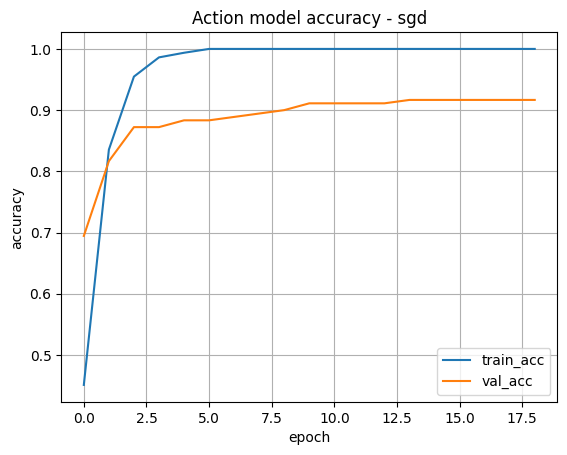

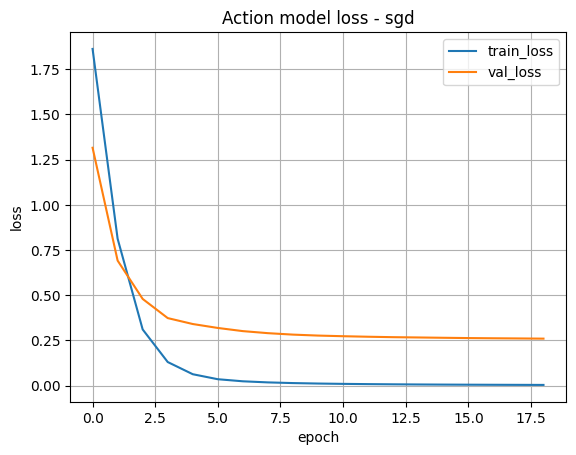

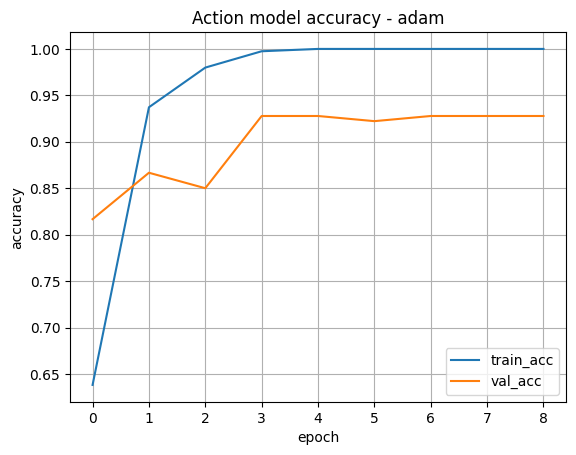

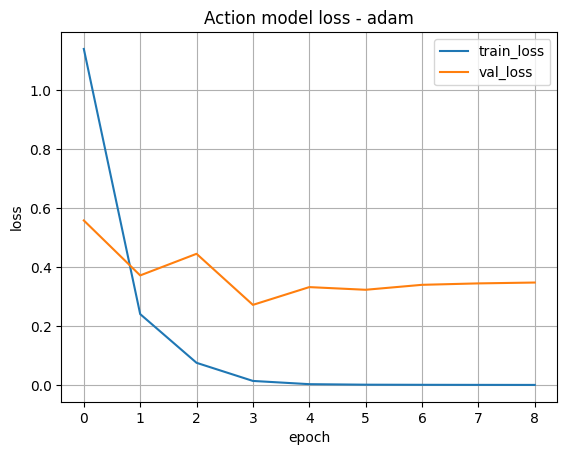

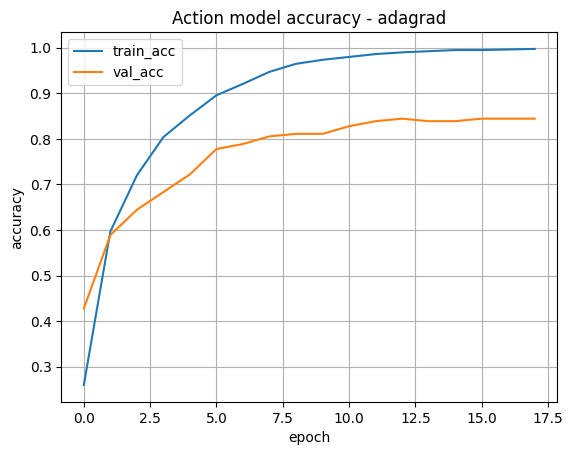

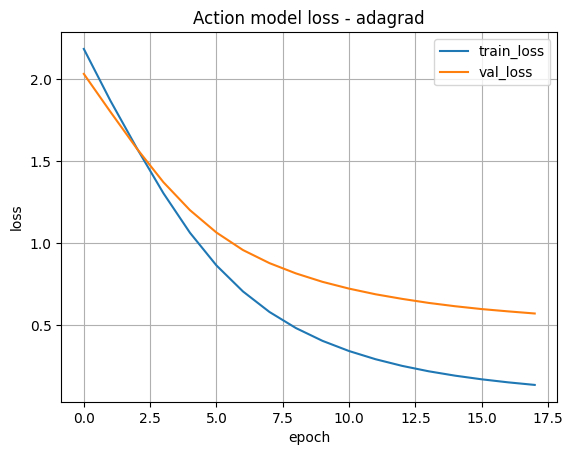

In [12]:
plot_history_curves(action_histories, title_prefix="Action model")

## **4.Model Testing & Visualization**

In [13]:
def test_random_video(model, X_test, y_test, class_names):
    idx = random.randint(0, len(X_test) - 1)

    video = X_test[idx]
    true_label = np.argmax(y_test[idx])

    pred = model.predict(video[np.newaxis, ...])[0]
    pred_label = np.argmax(pred)

    print("=====================================")
    print("Testing Random Video")
    print("True Label     :", class_names[true_label])
    print("Predicted Label:", class_names[pred_label])
    print("=====================================")

    plt.figure(figsize=(8, 8))
    for i in range(SEQUENCE_LENGTH):
        plt.subplot(4, 4, i + 1)
        plt.imshow(video[i])
        plt.axis("off")
    plt.suptitle(
        f"True: {class_names[true_label]}   |   Pred: {class_names[pred_label]}",
        fontsize=14
    )
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
Testing Random Video
True Label     : Bowling
Predicted Label: Bowling


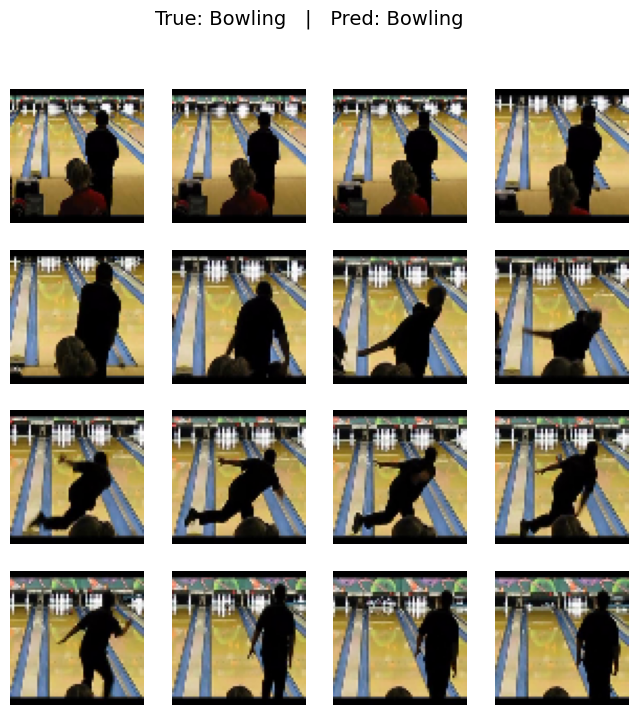

In [14]:
test_random_video(best_action_model, X_test_a, y_test_a, ACTION_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Testing Random Video
True Label     : BrushingTeeth
Predicted Label: BrushingTeeth


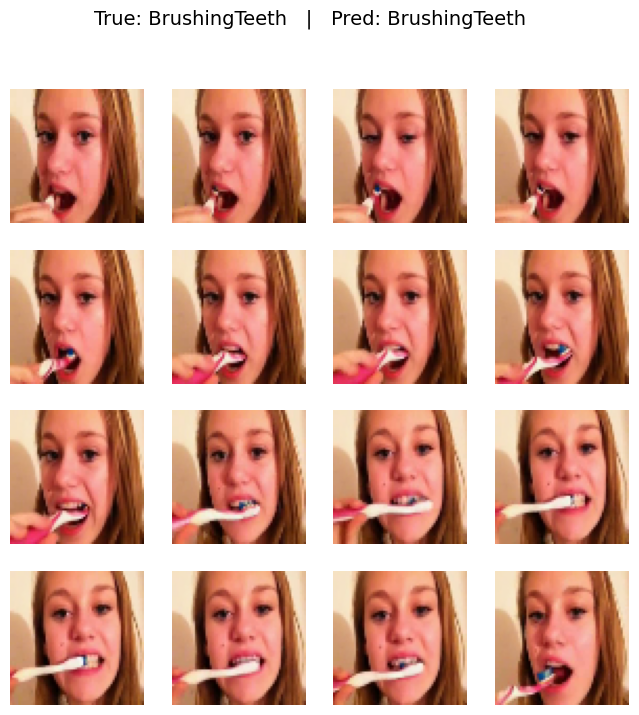

In [15]:
test_random_video(best_action_model, X_test_a, y_test_a, ACTION_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Testing Random Video
True Label     : Archery
Predicted Label: Archery


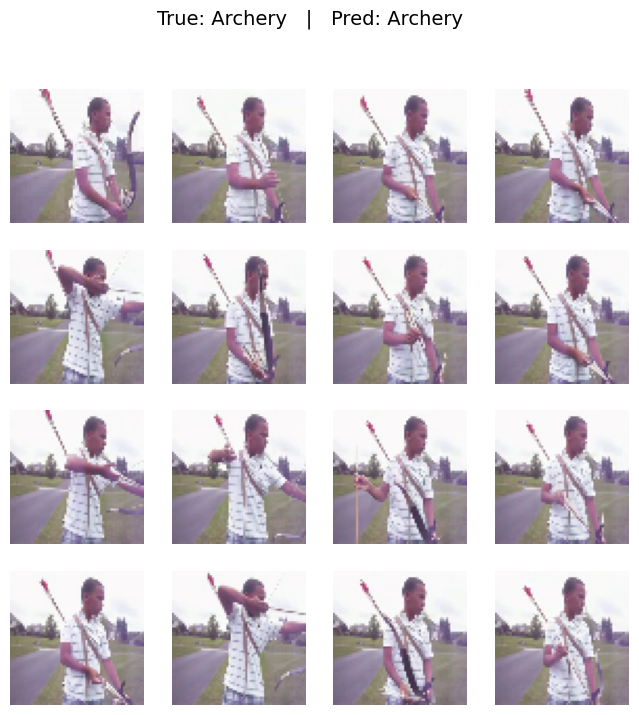

In [16]:
test_random_video(best_action_model, X_test_a, y_test_a, ACTION_CLASSES)

6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step


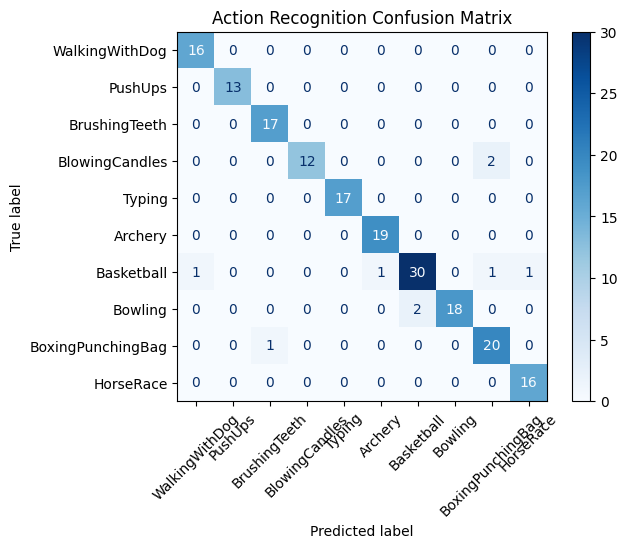

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred_probs = best_action_model.predict(X_test_a)      
y_pred = np.argmax(y_pred_probs, axis=1)               

# 2) Convert one-hot true labels to indices
y_true = np.argmax(y_test_a, axis=1)                  

# 3) Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)                  

# 4) Display confusion matrix with class names
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=ACTION_CLASSES)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Action Recognition Confusion Matrix")
plt.show()


## **5. Save Model**

In [18]:
best_action_model.save("action_cnn_lstm.h5")

In [19]:
best_action_model.save("action_cnn_lstm.keras")

# **Milestone 2: System Integration and Real-Time Implementation** 

In [24]:
import os
import time
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns

In [90]:
IMAGE_ROOT = "/kaggle/input/fer2013"
TRAIN_DIR = os.path.join(IMAGE_ROOT, "train")
TEST_DIR = os.path.join(IMAGE_ROOT, "test")
OUTPUT_DIR = "/kaggle/working/fer_vgg"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EMOTION_CLASSES = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
NUM_CLASSES = 7
BATCH_SIZE = 128
EPOCHS = 50
BASE_LR = 0.01
DROPOUT_PROB = 0.5
EMO_IMG_SIZE = 48

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [91]:
print(f"Using TensorFlow {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


Using TensorFlow 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## DATA LOADING & PREPROCESSING

In [92]:
def preprocess_image_clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return img

def load_emotion_data(root_dir, apply_clahe=True):
    X = []
    y = []
    label2idx = {cls: i for i, cls in enumerate(EMOTION_CLASSES)}
    
    if not os.path.isdir(root_dir):
        print(f"Directory not found: {root_dir}")
        return None, None, None
    
    class_counts = {cls: 0 for cls in EMOTION_CLASSES}
    
    for cls_name in EMOTION_CLASSES:
        cls_path = os.path.join(root_dir, cls_name)
        if not os.path.isdir(cls_path):
            print(f"Warning: class folder missing: {cls_path}")
            continue
        
        img_files = [f for f in os.listdir(cls_path)
                     if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
        
        for file in img_files:
            img_path = os.path.join(cls_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            
            img = cv2.resize(img, (EMO_IMG_SIZE, EMO_IMG_SIZE))
            
            if apply_clahe:
                img = preprocess_image_clahe(img)
            
            img = img.astype("float32") / 255.0
            X.append(img)
            y.append(label2idx[cls_name])
            class_counts[cls_name] += 1
    
    print(f"\nClass distribution in {root_dir}:")
    for cls, count in class_counts.items():
        print(f"  {cls}: {count} ({100*count/len(X):.1f}%)")
    
    X = np.array(X)
    X = np.expand_dims(X, -1)
    y = np.array(y)
    y_cat = to_categorical(y, num_classes=NUM_CLASSES)
    
    print(f"Loaded: {X.shape}, Labels: {y_cat.shape}\n")
    return X, y_cat, y


## Load data

In [61]:
X_train_full, y_train_full, y_train_int = load_emotion_data(TRAIN_DIR, apply_clahe=True)

X_test, y_test, _ = load_emotion_data(TEST_DIR, apply_clahe=True)

STEP 1: Loading training data...

Class distribution in /kaggle/input/fer2013/train:
  angry: 3995 (13.9%)
  disgust: 436 (1.5%)
  fear: 4097 (14.3%)
  happy: 7215 (25.1%)
  sad: 4830 (16.8%)
  surprise: 3171 (11.0%)
  neutral: 4965 (17.3%)
Loaded: (28709, 48, 48, 1), Labels: (28709, 7)

STEP 2: Loading test data...

Class distribution in /kaggle/input/fer2013/test:
  angry: 958 (13.3%)
  disgust: 111 (1.5%)
  fear: 1024 (14.3%)
  happy: 1774 (24.7%)
  sad: 1247 (17.4%)
  surprise: 831 (11.6%)
  neutral: 1233 (17.2%)
Loaded: (7178, 48, 48, 1), Labels: (7178, 7)



## Split train into train/val

In [63]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_int
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}\n")

STEP 3: Splitting train/validation...
Train: (24402, 48, 48, 1), Val: (4307, 48, 48, 1), Test: (7178, 48, 48, 1)



In [51]:
def get_data_generators():
    train_datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.15,
        zoom_range=0.15,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    
    return train_datagen

## MODEL ARCHITECTURE

In [52]:
def build_small_vgg(num_classes=NUM_CLASSES, dropout_prob=DROPOUT_PROB):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(64, (3,3), padding='same', input_shape=(EMO_IMG_SIZE, EMO_IMG_SIZE, 1)),
        layers.ReLU(),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.ReLU(),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        
        # Block 2
        layers.Conv2D(128, (3,3), padding='same'),
        layers.ReLU(),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same'),
        layers.ReLU(),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        
        # Block 3
        layers.Conv2D(256, (3,3), padding='same'),
        layers.ReLU(),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), padding='same'),
        layers.ReLU(),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        
        # Block 4
        layers.Conv2D(512, (3,3), padding='same'),
        layers.ReLU(),
        layers.BatchNormalization(),
        layers.Conv2D(512, (3,3), padding='same'),
        layers.ReLU(),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        
        # Classifier
        layers.Dense(1024),
        layers.ReLU(),
        layers.Dropout(dropout_prob),
        layers.Dense(512),
        layers.ReLU(),
        layers.Dropout(dropout_prob),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

## TRAINING UTILITIES

In [64]:
def get_optimizer(opt_name, lr):
    if opt_name == "sgd":
        return optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)
    elif opt_name == "adam":
        return optimizers.Adam(learning_rate=lr)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

def get_callbacks(output_dir, opt_name):
    reduce_lr = ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.75,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
    
    checkpoint = ModelCheckpoint(
        filepath=os.path.join(output_dir, f"best_model_{opt_name}.keras"),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    return [reduce_lr, checkpoint]

In [65]:
def train_with_single_optimizer(X_train, y_train, X_val, y_val,
                                opt_name, lr, epochs, batch_size):
    
    print(f"\n{'='*60}")
    print(f"Training EMOTION model with: {opt_name.upper()}")
    print(f"{'='*60}\n")
    
    # Build fresh model
    model = build_small_vgg(num_classes=NUM_CLASSES, dropout_prob=DROPOUT_PROB)
    print(f"Total params: {model.count_params():,}")
    
    # Compile
    optimizer = get_optimizer(opt_name, lr)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Data augmentation
    datagen = get_data_generators()
    
    # Callbacks
    callbacks = get_callbacks(OUTPUT_DIR, opt_name)
    
    # Train
    t0 = time.time()
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=batch_size),
        steps_per_epoch=len(X_train) // batch_size,
        validation_data=(X_val, y_val),
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    training_time = time.time() - t0
    
    # Get best results
    best_val_acc = max(history.history['val_accuracy'])
    best_epoch = np.argmax(history.history['val_accuracy']) + 1
    final_val_acc = history.history['val_accuracy'][-1]
    
    print(f"\n{opt_name.upper()} Results:")
    print(f"  Best val_acc:  {best_val_acc:.4f} (epoch {best_epoch})")
    print(f"  Final val_acc: {final_val_acc:.4f}")
    print(f"  Training time: {training_time/60:.1f} minutes")
    print(f"{'='*60}\n")
    
    return {
        'optimizer': opt_name,
        'model_path': os.path.join(OUTPUT_DIR, f"best_model_{opt_name}.keras"),
        'history': history,
        'best_val_acc': best_val_acc,
        'final_val_acc': final_val_acc,
        'training_time': training_time
    }

In [68]:
def compare_optimizers(X_train, y_train, X_val, y_val,
                       epochs=EPOCHS, batch_size=BATCH_SIZE):
    
    optimizers_config = {
        "sgd": {"lr": 0.01},
        "adam": {"lr": 0.001}
    }
    
    results = {}
    
    for opt_name, config in optimizers_config.items():
        result = train_with_single_optimizer(
            X_train, y_train, X_val, y_val,
            opt_name=opt_name,
            lr=config['lr'],
            epochs=epochs,
            batch_size=batch_size
        )
        results[opt_name] = result
    
    best_opt_name = max(results.keys(), key=lambda k: results[k]['best_val_acc'])
    best_result = results[best_opt_name]
    
    print(f"\n{'='*60}")
    print("OPTIMIZER COMPARISON")
    print(f"{'='*60}")
    for opt_name, result in results.items():
        print(f"{opt_name.upper():5s} - Best val_acc: {result['best_val_acc']:.4f} | "
              f"Time: {result['training_time']/60:.1f} min")
    print(f"\n BEST OPTIMIZER: {best_opt_name.upper()} "
          f"(val_acc: {best_result['best_val_acc']:.4f})")
    print(f"{'='*60}\n")
    
    return best_opt_name, best_result, results

In [71]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping

## Train & Compare optimizers

In [72]:
best_opt_name, best_result, all_results = compare_optimizers(
    X_train, y_train, X_val, y_val,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Training EMOTION model with: SGD

Total params: 5,745,607
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2551 - loss: 1.8129
Epoch 1: val_accuracy improved from -inf to 0.16810, saving model to /kaggle/working/fer_vgg/best_model_sgd.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 32s 106ms/step - accuracy: 0.2553 - loss: 1.8125 - val_accuracy: 0.1681 - val_loss: 2.1107 - learning_rate: 0.0100
Epoch 2/50
  1/190 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.3828 - loss: 1.6034

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.16810
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3828 - loss: 1.6034 - val_accuracy: 0.1681 - val_loss: 2.0661 - learning_rate: 0.0100
Epoch 3/50
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3957 - loss: 1.5452
Epoch 3: val_accuracy improved from 0.16810 to 0.22220, saving model to /kaggle/working/fer_vgg/best_model_sgd.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.3959 - loss: 1.5448 - val_accuracy: 0.2222 - val_loss: 2.1774 - learning_rate: 0.0100
Epoch 4/50
  1/190 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.5078 - loss: 1.3282
Epoch 4: val_accuracy did not improve from 0.22220
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5078 - loss: 1.3282 - val_accuracy: 0.2196 - val_loss: 2.2063 - learning_rate: 0.0100
Epoch 5/50
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4698 - loss: 1.3866
Epoch 5: val_accuracy improved from 0.22220 to 0.47876, saving model to /kaggle/working/fer_vg

## Plot optimizer comparison

STEP 5: Plotting optimizer comparison...
Optimizer comparison plot saved: /kaggle/working/fer_vgg/optimizer_comparison.png


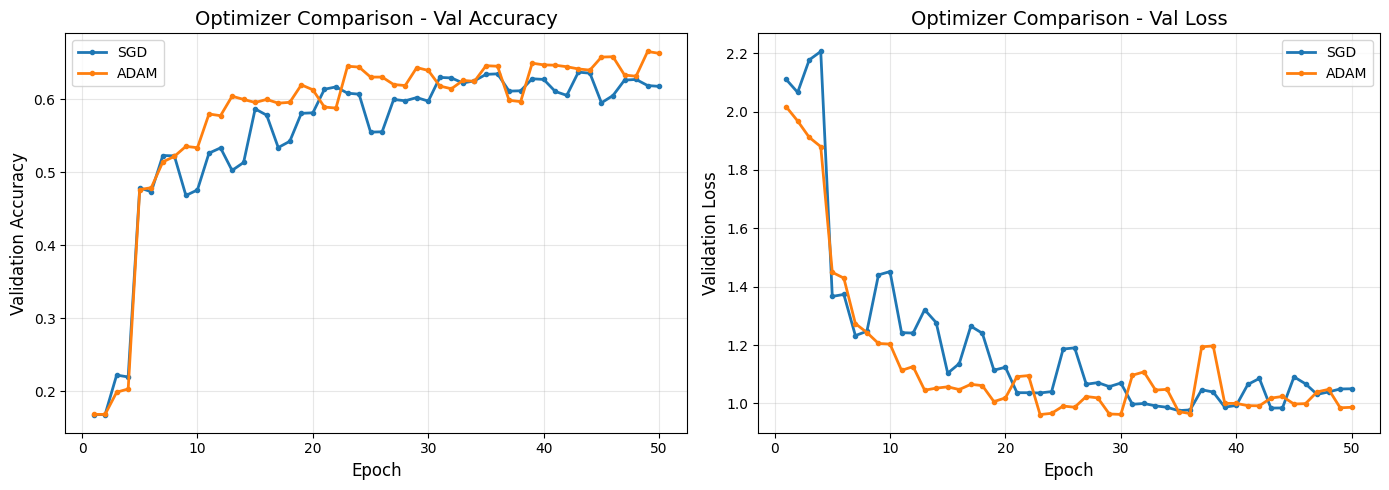

In [78]:
plot_optimizer_comparison(all_results, 
                         savepath=os.path.join(OUTPUT_DIR, "optimizer_comparison.png"))

## Plot training curves

STEP 6: Plotting training curves for best optimizer (ADAM)...
Training curves saved: /kaggle/working/fer_vgg/training_curves_adam.png


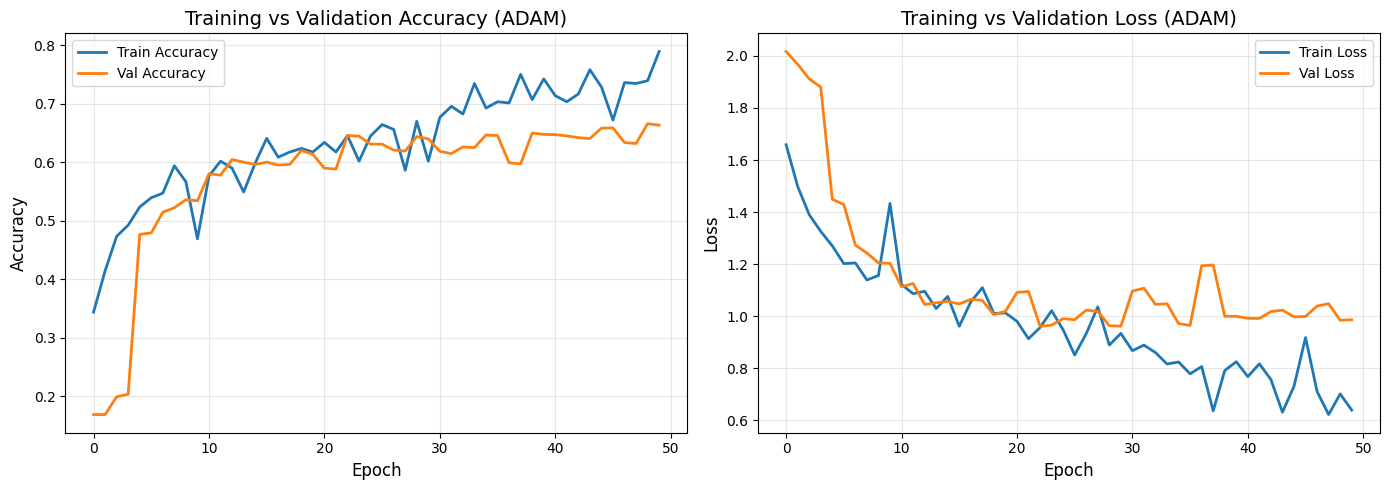

In [79]:
print(f"STEP 6: Plotting training curves for best optimizer ({best_opt_name.upper()})...")
plot_training_curves(best_result['history'], 
                    title_suffix=f"({best_opt_name.upper()})",
                    savepath=os.path.join(OUTPUT_DIR, f"training_curves_{best_opt_name}.png"))

## Evaluate best model on test set

In [94]:
print(f"Evaluating best model ({best_opt_name.upper()}) on test set")
best_model, test_loss, test_acc = evaluate_model(best_result['model_path'], X_test, y_test)

Evaluating best model (ADAM) on test set

TEST SET EVALUATION
Test Loss:     1.0098
Test Accuracy: 0.6534



## Get predictions and metrics

In [95]:
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = get_predictions(best_model, X_test, y_test)

print_classification_report(y_true, y_pred)
print_per_class_accuracy(y_true, y_pred)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

       angry      0.587     0.588     0.587       958
     disgust      0.586     0.523     0.552       111
        fear      0.560     0.331     0.416      1024
       happy      0.860     0.870     0.865      1774
         sad      0.499     0.603     0.546      1247
    surprise      0.751     0.804     0.776       831
     neutral      0.579     0.622     0.600      1233

    accuracy                          0.653      7178
   macro avg      0.632     0.620     0.620      7178
weighted avg      0.653     0.653     0.648      7178


Per-Class Accuracy:
------------------------------
  angry     : 58.77%
  disgust   : 52.25%
  fear      : 33.11%
  happy     : 86.98%
  sad       : 60.30%
  surprise  : 80.39%
  neutral   : 62.21%
------------------------------


## confusion matrix

Confusion matrix saved: /kaggle/working/fer_vgg/confusion_matrix_adam.png


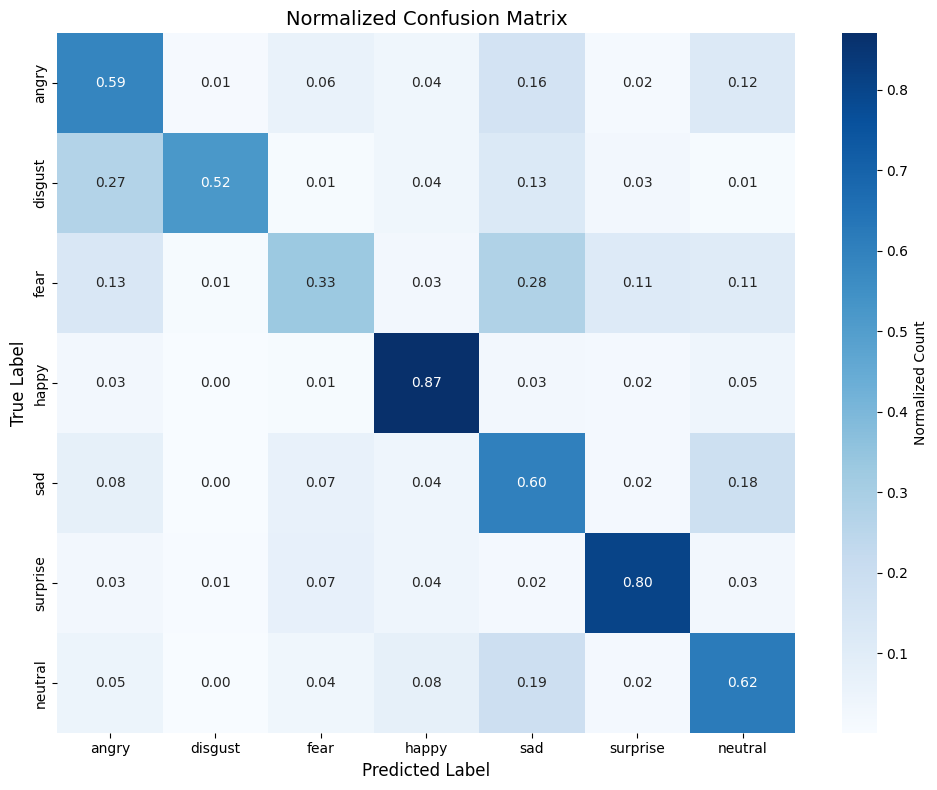

In [96]:
import seaborn as sns
plot_confusion_matrix(y_true, y_pred,
                     savepath=os.path.join(OUTPUT_DIR, f"confusion_matrix_{best_opt_name}.png"),
                     normalize=True)

## FINE-TUNING FUNCTION

In [73]:
def fine_tune_model(model_path, X_train, y_train, X_val, y_val,
                    lr=1e-4, extra_epochs=20, batch_size=BATCH_SIZE):
    """Fine-tune best model with lower learning rate"""
    
    print(f"\n{'='*60}")
    print("Fine-tuning best model...")
    print(f"{'='*60}\n")
    
    # Load best model
    model = tf.keras.models.load_model(model_path)
    
    # Recompile with lower LR (SGD for fine-tuning)
    optimizer = optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Data augmentation
    datagen = get_data_generators()
    
    # Checkpoint for fine-tuned model
    checkpoint = ModelCheckpoint(
        filepath=os.path.join(OUTPUT_DIR, "fine_tuned_best.keras"),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    # Fine-tune
    t0 = time.time()
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=batch_size),
        steps_per_epoch=len(X_train) // batch_size,
        validation_data=(X_val, y_val),
        epochs=extra_epochs,
        callbacks=[checkpoint],
        verbose=1
    )
    
    best_val_acc = max(history.history['val_accuracy'])
    print(f"\nFine-tuning completed in {(time.time()-t0)/60:.1f} minutes")
    print(f"Best val_acc after fine-tuning: {best_val_acc:.4f}")
    
    return model, history

In [85]:
model_ft, history_ft = fine_tune_model(
    best_result['model_path'],
    X_train, y_train, X_val, y_val,
    lr=1e-4,
    extra_epochs=20
)


Fine-tuning best model...

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7513 - loss: 0.6681
Epoch 1: val_accuracy improved from -inf to 0.67054, saving model to /kaggle/working/fer_vgg/fine_tuned_best.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.7513 - loss: 0.6681 - val_accuracy: 0.6705 - val_loss: 0.9781
Epoch 2/20
  1/190 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.7500 - loss: 0.7515

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.67054 to 0.67077, saving model to /kaggle/working/fer_vgg/fine_tuned_best.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7500 - loss: 0.7515 - val_accuracy: 0.6708 - val_loss: 0.9783
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7533 - loss: 0.6654
Epoch 3: val_accuracy did not improve from 0.67077
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.7533 - loss: 0.6654 - val_accuracy: 0.6664 - val_loss: 0.9811
Epoch 4/20
  1/190 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.7500 - loss: 0.7192
Epoch 4: val_accuracy did not improve from 0.67077
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7500 - loss: 0.7192 - val_accuracy: 0.6668 - val_loss: 0.9813
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7593 - loss: 0.6555
Epoch 5: val_accuracy did not improve from 0.67077
190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.7593 - loss: 0.6555 - val_accuracy: 0.6678 - val_loss: 0.

## EVALUATION FUNCTIONS

In [74]:
def evaluate_model(model_path, X_test, y_test):
    """Evaluate model on test set"""
    model = tf.keras.models.load_model(model_path)
    
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n{'='*60}")
    print("TEST SET EVALUATION")
    print(f"{'='*60}")
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"{'='*60}\n")
    
    return model, test_loss, test_acc

def get_predictions(model, X_test, y_test):
    """Get predictions and compute confusion matrix"""
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    return y_true, y_pred

def print_classification_report(y_true, y_pred):
    """Print detailed classification report"""
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60 + "\n")
    print(classification_report(y_true, y_pred, 
                                target_names=EMOTION_CLASSES, 
                                digits=3))

def print_per_class_accuracy(y_true, y_pred):
    """Print per-class accuracy from confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    print("\nPer-Class Accuracy:")
    print("-" * 30)
    for i, cls in enumerate(EMOTION_CLASSES):
        cls_acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
        print(f"  {cls:10s}: {cls_acc:.2%}")
    print("-" * 30)

## VISUALIZATION FUNCTIONS

In [57]:
def plot_confusion_matrix(y_true, y_pred, savepath=None, normalize=True):
    """Plot confusion matrix heatmap"""
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm_plot = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        title = 'Normalized Confusion Matrix'
        fmt = '.2f'
    else:
        cm_plot = cm
        title = 'Confusion Matrix (Counts)'
        fmt = 'd'
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=EMOTION_CLASSES,
                yticklabels=EMOTION_CLASSES,
                cbar_kws={'label': 'Normalized Count' if normalize else 'Count'})
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(title, fontsize=14)
    plt.tight_layout()
    
    if savepath:
        plt.savefig(savepath, dpi=150)
        print(f"Confusion matrix saved: {savepath}")
    plt.show()



TEST SET EVALUATION
Test Loss:     1.0141
Test Accuracy: 0.6481


CLASSIFICATION REPORT

              precision    recall  f1-score   support

       angry      0.522     0.629     0.570       958
     disgust      0.619     0.468     0.533       111
        fear      0.535     0.358     0.429      1024
       happy      0.879     0.854     0.866      1774
         sad      0.529     0.549     0.538      1247
    surprise      0.770     0.764     0.767       831
     neutral      0.565     0.646     0.603      1233

    accuracy                          0.648      7178
   macro avg      0.631     0.610     0.615      7178
weighted avg      0.651     0.648     0.646      7178


Per-Class Accuracy:
------------------------------
  angry     : 62.94%
  disgust   : 46.85%
  fear      : 35.84%
  happy     : 85.40%
  sad       : 54.85%
  surprise  : 76.41%
  neutral   : 64.56%
------------------------------
Confusion matrix saved: /kaggle/working/fer_vgg/confusion_matrix_finetuned.png


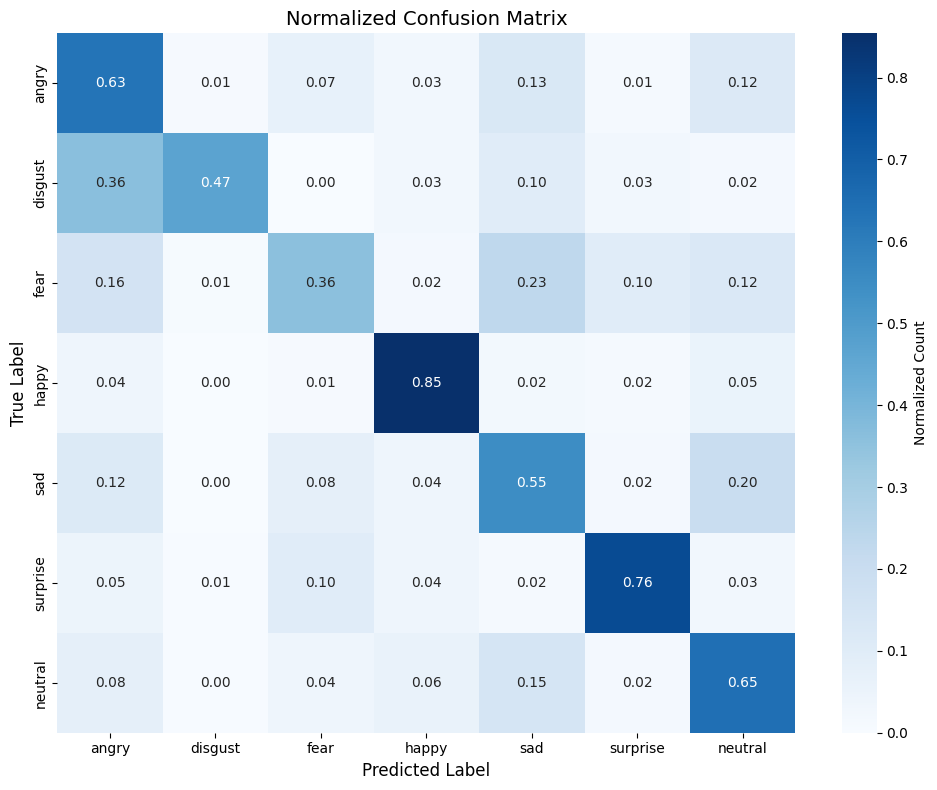

In [89]:
ft_model_path = os.path.join(OUTPUT_DIR, "fine_tuned_best.keras")
model_ft, test_loss_ft, test_acc_ft = evaluate_model(ft_model_path, X_test, y_test)

y_true_ft, y_pred_ft = get_predictions(model_ft, X_test, y_test)
print_classification_report(y_true_ft, y_pred_ft)
print_per_class_accuracy(y_true_ft, y_pred_ft)

plot_confusion_matrix(y_true_ft, y_pred_ft,
                     savepath=os.path.join(OUTPUT_DIR, "confusion_matrix_finetuned.png"),
                     normalize=True)

In [75]:
def plot_training_curves(history, title_suffix="", savepath=None):
    """Plot training and validation accuracy/loss curves"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title(f'Training vs Validation Accuracy {title_suffix}', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title(f'Training vs Validation Loss {title_suffix}', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if savepath:
        plt.savefig(savepath, dpi=150)
        print(f"Training curves saved: {savepath}")
    plt.show()

def plot_optimizer_comparison(results, savepath=None):
    """Compare optimizer performance side-by-side"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for opt_name, result in results.items():
        history = result['history'].history
        epochs = range(1, len(history['val_accuracy']) + 1)
        
        # Validation accuracy
        axes[0].plot(epochs, history['val_accuracy'], 
                    label=f"{opt_name.upper()}", linewidth=2, marker='o', markersize=3)
        
        # Validation loss
        axes[1].plot(epochs, history['val_loss'], 
                    label=f"{opt_name.upper()}", linewidth=2, marker='o', markersize=3)
    
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Validation Accuracy', fontsize=12)
    axes[0].set_title('Optimizer Comparison - Val Accuracy', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Validation Loss', fontsize=12)
    axes[1].set_title('Optimizer Comparison - Val Loss', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if savepath:
        plt.savefig(savepath, dpi=150)
        print(f"Optimizer comparison plot saved: {savepath}")
    plt.show()

In [76]:
def visualize_sample_predictions(model, X_test, y_test, num_samples=8):
    """Visualize sample predictions with true/predicted labels"""
    indices = np.random.choice(len(X_test), num_samples, replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    y_pred = np.argmax(model.predict(X_test[indices], verbose=0), axis=1)
    y_true = np.argmax(y_test[indices], axis=1)
    
    for i, idx in enumerate(indices):
        axes[i].imshow(X_test[idx].squeeze(), cmap='gray')
        true_label = EMOTION_CLASSES[y_true[i]]
        pred_label = EMOTION_CLASSES[y_pred[i]]
        color = 'green' if y_true[i] == y_pred[i] else 'red'
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", 
                         color=color, fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()


STEP 12: Generating visualizations...


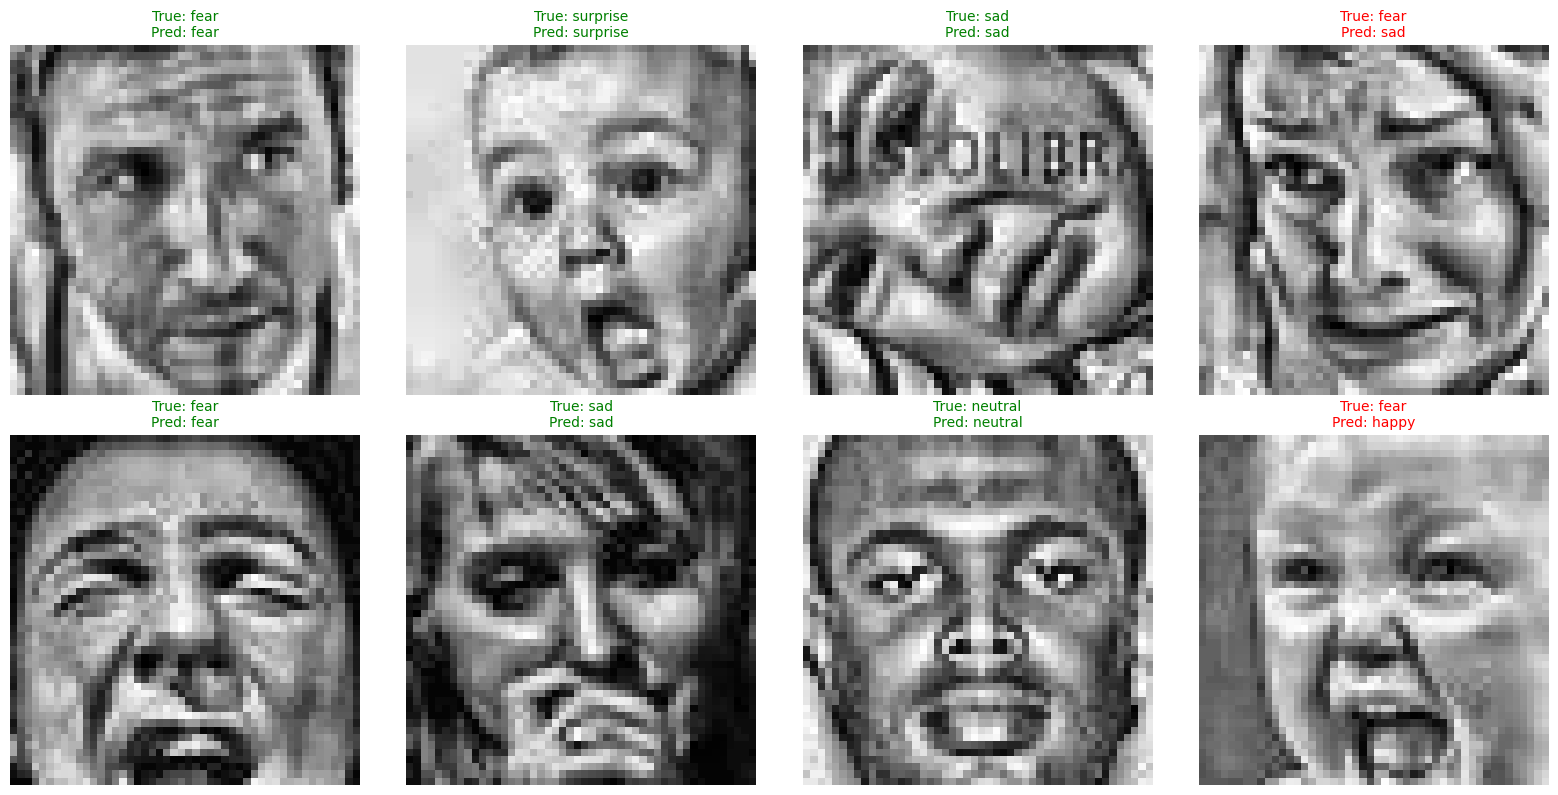


Best Optimizer: ADAM
Best Val Accuracy: 0.6657
Final Test Accuracy: 0.6481



In [88]:
visualize_sample_predictions(model_ft, X_test, y_test, num_samples=8)


print("\n" + "="*60)
print(f"Best Optimizer: {best_opt_name.upper()}")
print(f"Best Val Accuracy: {best_result['best_val_acc']:.4f}")
print(f"Final Test Accuracy: {test_acc_ft:.4f}")
print("="*60 + "\n")